# 04_vrr12_investigation

## 目标
围绕 `VRR12` 做专项排查，回答下面 3 个问题：

1. `VRR12` 的突变更像是**传感器随机故障**，还是**量纲 / 缩放 / 表示方式切换**？
2. `VRR12` 的 jump 点到底发生在什么位置？
3. 去掉 `VRR12` 以后，主异常窗口是否仍然存在？

---

## 基于当前分析的已知现象
根据前面的探索分析，已经观察到：

- `VRR12` 在大部分区间稳定在 **19.06 左右**
- 在 `Readings ≈ 12001` 附近，`VRR12` 跳到 **0.19 左右**
- 其他区间中位数与 jump 后区间中位数的比例约为 **99.31**
- jump 后如果对 `VRR12` 做 `×100` 修正，曲线可基本接回 pre-jump 平台
- `12115 ~ 12135` 这一段是主异常窗口，但它发生在 `VRR12` 已经进入低平台之后

因此，本 notebook 的重点不是“证明 VRR12 一定故障”，而是：

> 用数据去判断：`VRR12` 更像是 **背景状态切换下的可疑表示变量**，还是普通随机故障。


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)


## 1. 读取数据并做最基础清洗

说明：
- 本 notebook 默认位于 `notebooks/` 文件夹下
- 数据文件位于 `../data/PWR Abnormality Dataset.csv`
- 这里只处理和当前分析相关的一个已知问题：`Flow2` 中存在逗号小数格式


In [2]:
df = pd.read_csv("../data/PWR Abnormality Dataset.csv")

# 清洗 Flow2
df["Flow2"] = df["Flow2"].astype(str).str.strip().str.replace(",", ".", regex=False)
df["Flow2"] = pd.to_numeric(df["Flow2"], errors="coerce")

print("数据形状：", df.shape)
display(df.head())


数据形状： (12267, 17)


,Readings,Temperature,Pressure,Flow1,Flow2,VRR12,VRR22,VRR23,VRR33,VRS01,VRS03,VRS21,VRS31,VRS02,VRI01,VRI02,VRI03
0,1,248.852987,9.689813,4462.130014,13302.92650,19.060938,0.059119,0.050589,0.111864,0.033951,0.047812,0.232627,0.253775,0.400726,1.763223,0.003031,0.004995
1,2,269.315740,1.279532,4480.252595,13784.45225,19.062128,0.059089,0.048788,0.111340,0.034060,0.052611,0.233342,0.315067,0.128517,1.769272,0.003164,0.004999
2,3,94.320644,6.280686,4325.270376,12899.98773,19.061641,0.058145,0.048552,0.111118,0.033859,0.053999,0.233387,0.380191,0.321816,1.768585,0.003321,0.004996
3,4,271.019823,0.669886,4481.761795,13733.00610,19.062453,0.058236,0.049514,0.112658,0.034049,0.050767,0.233850,0.329846,0.132092,1.772432,0.003061,0.004998
4,5,207.876262,6.806043,4425.839490,13500.22222,19.061101,0.058378,0.049809,0.111252,0.033996,0.052669,0.233619,0.390729,0.247973,1.772356,0.003060,0.004994


## 2. 定义两个关键区间

- `main anomaly window`：主异常窗口，来自前面异常检测结果，取 `12115 ~ 12135`
- `vrr12 jump`：后面会通过差分和阈值法重新定位


In [3]:
window_start, window_end = 12115, 12135

window_df = df[(df["Readings"] >= window_start) & (df["Readings"] <= window_end)].copy()
other_df = df[~((df["Readings"] >= window_start) & (df["Readings"] <= window_end))].copy()

print("主异常窗口大小：", window_df.shape)
print("其余区间大小：", other_df.shape)


主异常窗口大小： (21, 17)
其余区间大小： (12246, 17)


## 3. 先看 VRR12 的全局现象

如果 `VRR12` 是普通噪声型故障，通常会看到：
- 漂移
- 毛刺
- 抖动
- 不规则波动

如果 `VRR12` 是量纲 / 表示方式切换，则更可能看到：
- 两个稳定平台
- 在某一点发生台阶式突变
- jump 后仍然很稳定


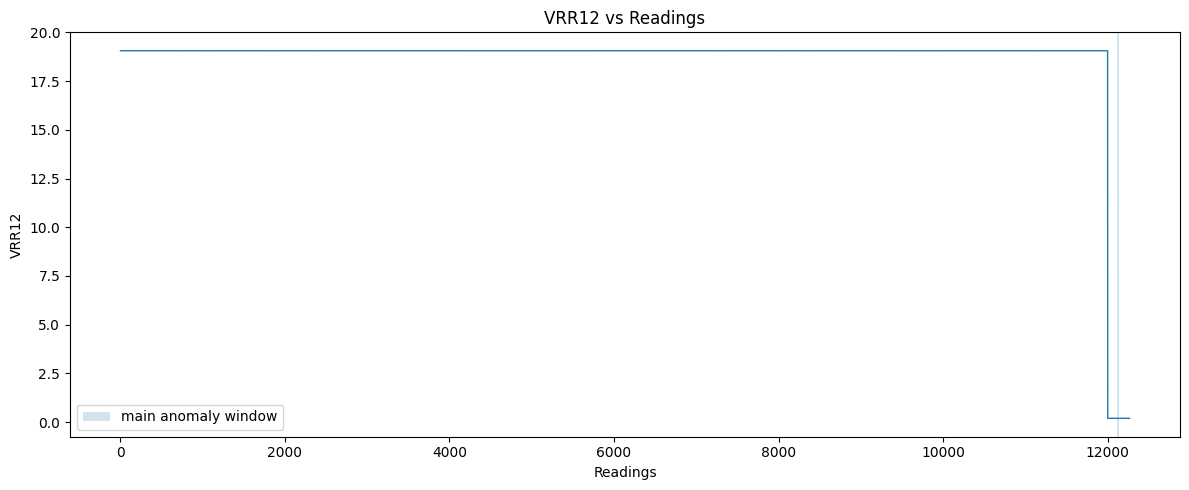

In [4]:
plt.figure(figsize=(12, 5))
plt.plot(df["Readings"], df["VRR12"], linewidth=1)
plt.axvspan(window_start, window_end, alpha=0.2, label="main anomaly window")
plt.xlabel("Readings")
plt.ylabel("VRR12")
plt.title("VRR12 vs Readings")
plt.legend()
plt.tight_layout()
plt.show()


### 初步观察
如果图像
- pre-jump：`VRR12 ≈ 19.06`
- post-jump：`VRR12 ≈ 0.19`
- jump 后不是乱跳，而是进入另一个很稳定的平台

这类“稳定双平台”更像**确定性切换**，而不是随机故障。


## 4. 描述统计：全局 / 主异常窗口 / 其他区间


In [5]:
print("全局 VRR12 描述统计：")
print(df["VRR12"].describe())

print("\n主异常窗口 VRR12 描述统计：")
print(window_df["VRR12"].describe())

print("\n其他区间 VRR12 描述统计：")
print(other_df["VRR12"].describe())


全局 VRR12 描述统计：
count    12267.000000
mean        18.651021
std          2.753532
min          0.190607
25%         19.061180
50%         19.061712
75%         19.062237
max         19.062778
Name: VRR12, dtype: float64

主异常窗口 VRR12 描述统计：
count    21.000000
mean      0.191914
std       0.000103
min       0.191664
25%       0.191863
50%       0.191935
75%       0.191955
max       0.192128
Name: VRR12, dtype: float64

其他区间 VRR12 描述统计：
count    12246.000000
mean        18.682676
std          2.647561
min          0.190607
25%         19.061183
50%         19.061713
75%         19.062238
max         19.062778
Name: VRR12, dtype: float64


### 如何读这张表
重点看：
- `50%`（中位数）
- `std`（标准差）
- `min / max`

如果看到：
- 其他区间中位数接近 `19.06`
- 窗口中位数接近 `0.19`
- 窗口标准差极小

那说明 `VRR12` 在当前窗口内不是乱跳，而是稳定处在另一个量级。


## 5. 比例检查：是否接近 100 倍？
这是判断“缩放 / 表示方式问题”的关键证据之一。


In [6]:
window_median = window_df["VRR12"].median()
other_median = other_df["VRR12"].median()
ratio = other_median / window_median

print("主异常窗口 VRR12 中位数：", window_median)
print("其他区间 VRR12 中位数：", other_median)
print("比例 other/window：", ratio)


主异常窗口 VRR12 中位数： 0.191935
其他区间 VRR12 中位数： 19.061713085
比例 other/window： 99.3133773673379


### 如何解释
如果比例非常接近 `100`，说明：

> 这更像“同一个量被缩小了 100 倍”，而不是普通物理波动。


## 6. 窗口内是否“卡死”或高度稳定？

这里看两个指标：

1. 标准差是否极小  
2. 唯一值个数是否很少


In [7]:
print("主异常窗口 VRR12 标准差：", window_df["VRR12"].std())
print("其他区间 VRR12 标准差：", other_df["VRR12"].std())

print("\n主异常窗口 VRR12 唯一值个数：", window_df["VRR12"].nunique())
print("其他区间 VRR12 唯一值个数：", other_df["VRR12"].nunique())


主异常窗口 VRR12 标准差： 0.00010313509402258556
其他区间 VRR12 标准差： 2.6475610969742824

主异常窗口 VRR12 唯一值个数： 20
其他区间 VRR12 唯一值个数： 11850


### 如何解释
如果窗口内：
- 标准差极小
- 唯一值个数显著更少

则说明它不是随机噪声，更像：
- 稳态平台
- 某种固定比例缩放后的窄范围波动
- 状态切换后的新表示形式


## 7. 定位真正的 jump 点

前面主异常窗口是 `12115 ~ 12135`，但这不一定是 `VRR12` 真正 jump 的位置。  
下面用两种办法来定位：

1. 差分绝对值最大点  
2. `VRR12 < 1` 的起始位置


In [8]:
df["VRR12_diff_abs"] = df["VRR12"].diff().abs()

print("VRR12 最大变化前10个点：")
display(
    df.sort_values(by="VRR12_diff_abs", ascending=False).head(10)[
        ["Readings", "VRR12", "VRR12_diff_abs", "Temperature", "Pressure", "Flow1", "Flow2"]
    ]
)


VRR12 最大变化前10个点：


,Readings,VRR12,VRR12_diff_abs,Temperature,Pressure,Flow1,Flow2
12000,12001,0.192685,18.868109,122.367200,16.204470,4319.400000,12958.30000
5347,5348,19.060707,0.002061,254.957231,11.926313,4467.536161,12629.49911
5912,5913,19.062771,0.002058,83.227036,2.231064,4315.445462,12696.43190
4390,4391,19.062761,0.002052,210.143458,4.063724,4427.847404,12264.44325
7887,7888,19.062747,0.002030,78.866218,12.558649,4311.583357,12385.67403
2827,2828,19.060716,0.002028,259.982449,8.544072,4471.986683,13857.00166
9021,9022,19.060700,0.002027,187.883534,14.803654,4408.133180,13529.38304
2826,2827,19.062744,0.002027,290.437390,2.500751,4498.958720,13417.14516
6948,6949,19.062743,0.002025,141.792611,4.456679,4367.313331,13934.11797
5932,5933,19.062741,0.002023,235.030680,4.058308,4449.888461,12174.21959


In [9]:
low_vrr12_df = df[df["VRR12"] < 1].copy()

print("VRR12 < 1 的前10个点：")
display(low_vrr12_df.head(10)[["Readings", "VRR12", "Temperature", "Pressure", "Flow1", "Flow2"]])

print("VRR12 < 1 的起始 Reading：", low_vrr12_df["Readings"].min())


VRR12 < 1 的前10个点：


,Readings,VRR12,Temperature,Pressure,Flow1,Flow2
12000,12001,0.192685,122.3672,16.20447,4319.400000,12958.3000
12001,12002,0.192208,123.7412,12.53043,4330.300000,13022.2400
12002,12003,0.192344,123.3299,10.28875,4341.400000,13004.2000
12003,12004,0.192087,123.2017,10.25380,4364.400000,13077.1000
12004,12005,0.192164,123.2022,12.11743,4375.500000,13130.2000
12005,12006,0.191932,122.9665,15.24106,4396.700000,13170.6000
12006,12007,0.191773,121.2773,15.55021,4407.800000,13210.2000
12007,12008,0.192074,119.5550,15.58955,4419.000000,13236.9000
12008,12009,0.191930,118.5685,15.61386,4322.771613,14342.8605
12009,12010,0.191962,118.2620,15.62080,4436.790155,14753.1730


VRR12 < 1 的起始 Reading： 12001


### 预期结论
如果和前面的探索一致，`VRR12` 的 jump 点应当出现在：

> **Readings = 12001**

这说明：
- `VRR12` 的背景切换早于主异常窗口
- 主异常窗口发生在 post-jump 的 regime 内部


## 8. 围绕 jump 点画局部图
目的：看 `VRR12` 的 jump 是否与温度、压力的阶段变化同步发生。


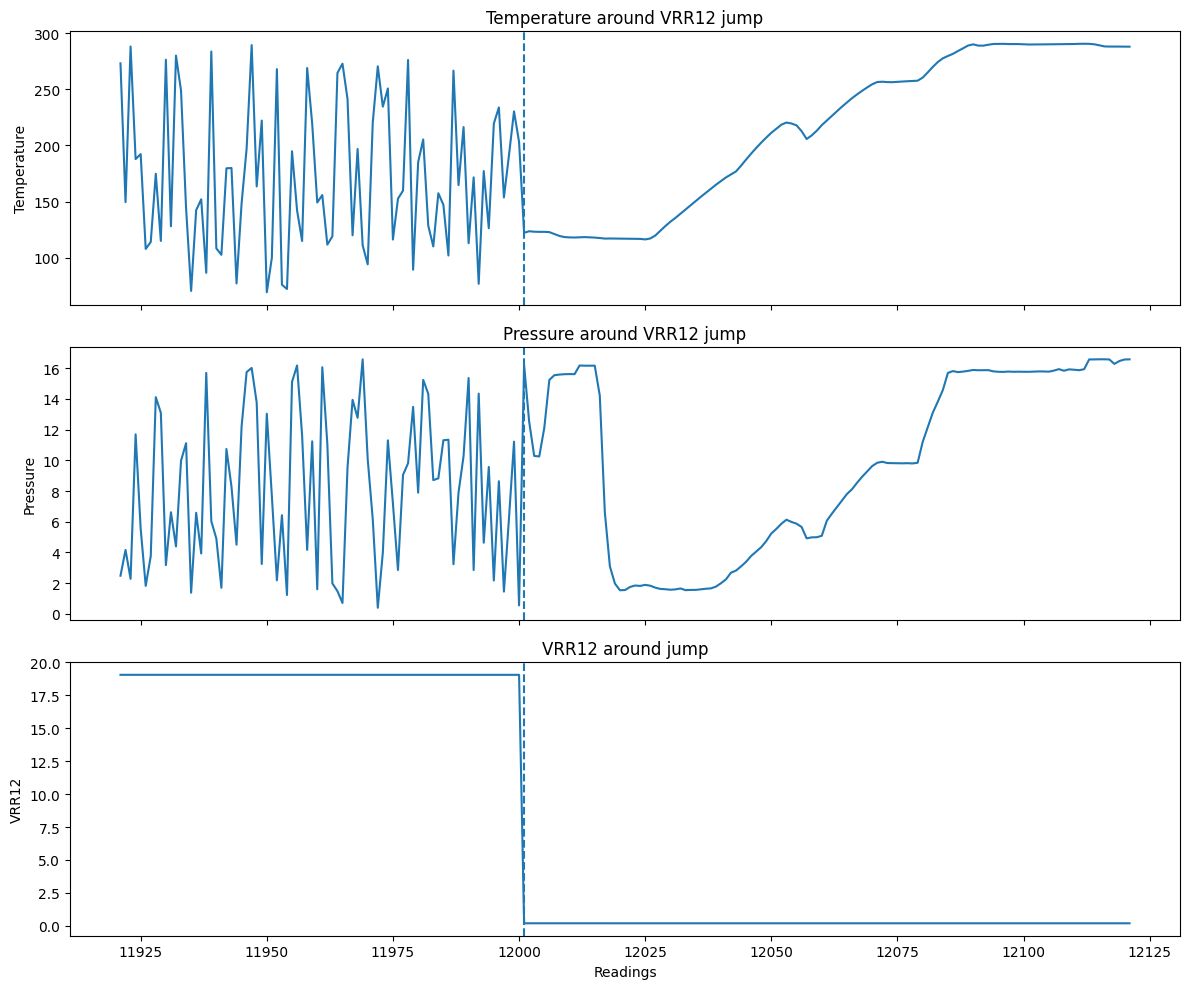

In [10]:
jump_reading = int(low_vrr12_df["Readings"].min())

jump_df = df[(df["Readings"] >= jump_reading - 80) & (df["Readings"] <= jump_reading + 120)].copy()

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].plot(jump_df["Readings"], jump_df["Temperature"])
axes[0].axvline(jump_reading, linestyle="--")
axes[0].set_ylabel("Temperature")
axes[0].set_title("Temperature around VRR12 jump")

axes[1].plot(jump_df["Readings"], jump_df["Pressure"])
axes[1].axvline(jump_reading, linestyle="--")
axes[1].set_ylabel("Pressure")
axes[1].set_title("Pressure around VRR12 jump")

axes[2].plot(jump_df["Readings"], jump_df["VRR12"])
axes[2].axvline(jump_reading, linestyle="--")
axes[2].set_ylabel("VRR12")
axes[2].set_xlabel("Readings")
axes[2].set_title("VRR12 around jump")

plt.tight_layout()
plt.show()


### 这一格怎么读
如果你看到：
- `Temperature / Pressure` 在 `12001` 附近也进入新的运行段
- 但 `VRR12` 的变化比它们更“整”、更像缩放台阶

那更合理的解释就是：

> 这里既有真实工况切换，也有 `VRR12` 表示方式可疑的问题。


## 9. 看 VRR 组是否同步变化
如果只有 `VRR12` 自己发生量级跳变，而 `VRR22 / VRR23 / VRR33` 没有同步类似变化，
则更像单变量表示异常，而不是整组一起切换。


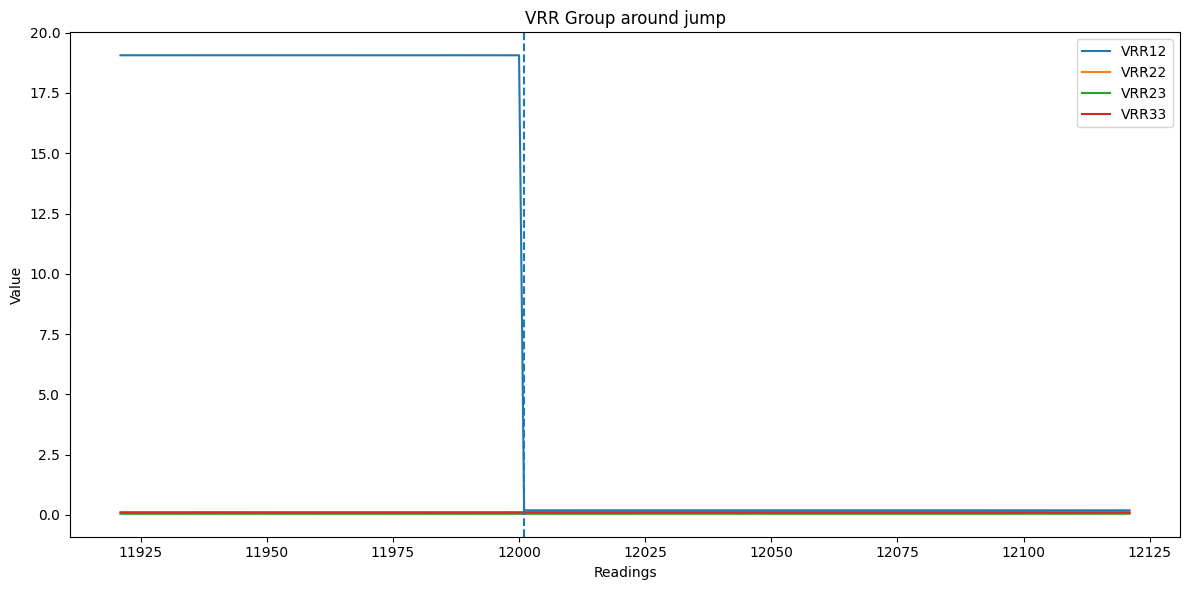

In [11]:
plt.figure(figsize=(12, 6))
plt.plot(jump_df["Readings"], jump_df["VRR12"], label="VRR12")
plt.plot(jump_df["Readings"], jump_df["VRR22"], label="VRR22")
plt.plot(jump_df["Readings"], jump_df["VRR23"], label="VRR23")
plt.plot(jump_df["Readings"], jump_df["VRR33"], label="VRR33")
plt.axvline(jump_reading, linestyle="--")
plt.xlabel("Readings")
plt.ylabel("Value")
plt.title("VRR Group around jump")
plt.legend()
plt.tight_layout()
plt.show()


### 这一格怎么读
- 如果只有 `VRR12` 掉量级，别的 `VRR` 变量没有同等表现  
  → 更像 `VRR12` 的单变量表示异常
- 如果整组都一起切换  
  → 更像真实状态切换 / 模式切换


## 10. post-jump ×100 修正试验


思路：
- 将 `jump_reading` 之后的 `VRR12` 全部乘以 100
- 观察是否能接回 pre-jump 平台


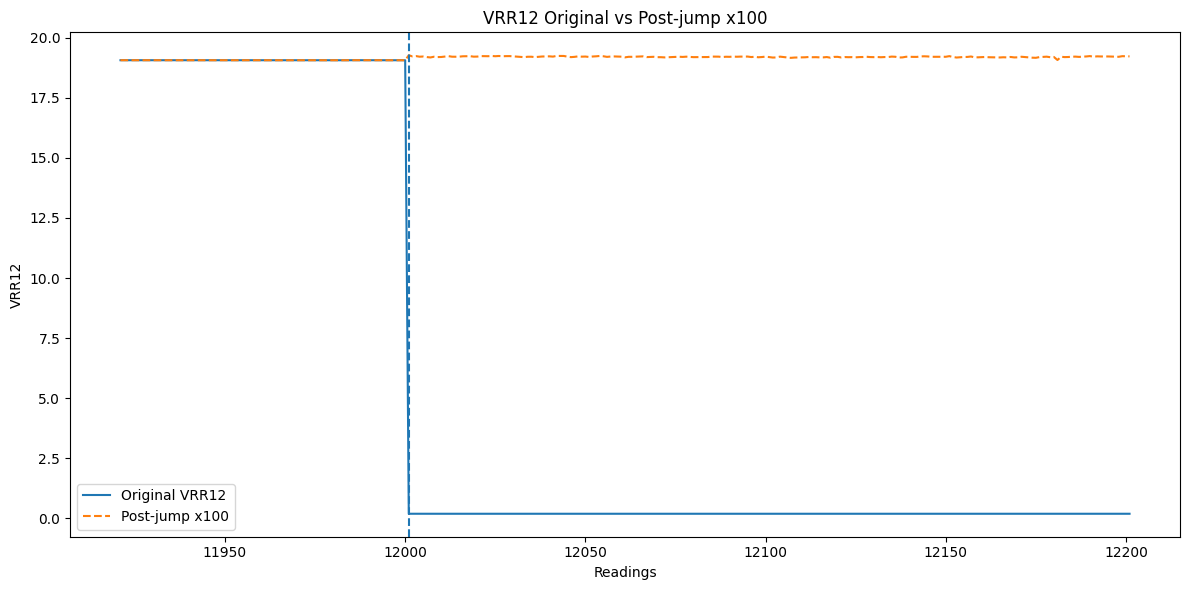

In [12]:
df_fix = df.copy()
df_fix["VRR12_fixed"] = df_fix["VRR12"]

df_fix.loc[df_fix["Readings"] >= jump_reading, "VRR12_fixed"] = (
    df_fix.loc[df_fix["Readings"] >= jump_reading, "VRR12_fixed"] * 100
)

fix_df = df_fix[(df_fix["Readings"] >= jump_reading - 80) & (df_fix["Readings"] <= jump_reading + 200)].copy()

plt.figure(figsize=(12, 6))
plt.plot(fix_df["Readings"], fix_df["VRR12"], label="Original VRR12")
plt.plot(fix_df["Readings"], fix_df["VRR12_fixed"], label="Post-jump x100", linestyle="--")
plt.axvline(jump_reading, linestyle="--")
plt.xlabel("Readings")
plt.ylabel("VRR12")
plt.title("VRR12 Original vs Post-jump x100")
plt.legend()
plt.tight_layout()
plt.show()


### 这一格怎么读
如果 `post-jump ×100` 后，虚线几乎能接回原来的 `19.06` 平台，  
则非常支持：

> `VRR12` 存在显著的缩放 / 表示方式切换问题。


## 11. 看 VRR12 最大值点
确认高平台本身是不是正常背景，而不是模型主要异常来源。


In [13]:
top10_vrr12 = df.sort_values(by="VRR12", ascending=False).head(10)

display(
    top10_vrr12[
        ["Readings", "VRR12", "Temperature", "Pressure", "Flow1", "Flow2"]
    ]
)


,Readings,VRR12,Temperature,Pressure,Flow1,Flow2
4573,4574,19.062778,229.595160,12.225039,4445.074560,12176.77340
8218,8219,19.062778,135.641685,5.356802,4361.865840,12683.56779
3831,3832,19.062777,173.851346,11.817918,4395.705748,12007.70736
4085,4086,19.062777,269.246372,3.405639,4480.191160,12939.38496
3147,3148,19.062777,245.127069,8.652924,4458.830201,13501.82283
10678,10679,19.062777,268.354015,11.657382,4479.400855,12833.95472
7848,7849,19.062777,141.433749,5.507041,4366.995509,13072.34075
3212,3213,19.062777,243.719898,7.623312,4457.583958,12847.68631
11296,11297,19.062776,96.487514,3.952478,4327.189438,13776.70485
7917,7918,19.062776,160.487563,12.562741,4383.870281,13891.17836


## 12. 阶段性结论（可直接用于项目总结草稿）

### 当前更合理的解释
基于当前证据，`VRR12` 更像：

- **背景状态切换下的可疑表示变量**
- 或者更具体地说：**存在缩放 / 量纲 / 表示方式切换嫌疑**

而不是典型的随机传感器故障。

### 支持证据
1. `VRR12` 在 `Readings ≈ 12001` 发生单步跳变  
2. jump 前后分别形成两个稳定平台：约 `19.06` 与 `0.19`  
3. 其他区间与窗口区间的中位数比例约为 **99.31**  
4. post-jump 区间在乘以 `100` 后可基本接回 pre-jump 平台  
5. 主异常窗口 `12115~12135` 发生在 `VRR12` 已进入低平台之后，因此 `VRR12` 的 jump 并不等同于主异常窗口本身

### 更稳妥的表述

> `VRR12` 在 `Readings=12001` 附近出现了显著量级切换，初步判断其更可能与缩放/表示方式变化有关，同时也可能与背景状态切换共同发生；因此，在后续异常检测中应将其视为特殊变量，进一步通过消融实验验证主异常窗口的稳健性。


## 13. 下一步建议
下一步最自然的是做消融实验：

1. **去掉 `VRR12` 后重跑异常检测**
2. 验证主异常窗口 `12115~12135` 是否仍然存在
3. 进一步区分：
   - 连续窗口异常
   - 孤立极端点异常
